## Hyperparameter Tuning using Optuna

### How Optuna works?

Optuna uses the **Bayesian Optimization Algorithm** as the base algorithm. In general, the usage process is quite simple. Can be summarized into 4 stages:

- We determine which parameters will be searched for values
- Optuna will "generate" the value of each parameter
- We define an evaluation function that measures how good the model is with the parameters that have been generated. Optuna will attempt to minimize (or maximize) the value produced by this evaluation function
- Run the search process by specifying limits when the search stops.

To do hyperparameter searching, Optuna needs `function obejective` which contains the parameters of the model that we want to tune so that we get the best score value

- Obejective function:
  - Takes trail object as input
  - Process:
    - Search Space
    - Model Init
    - Param Init
    - Training Loop
    - Evaluation Loop

````bash
import optuna

def objective(trial):
  ```code goes here```
  return evaluation_score

study = optuna.create_study()
study.optimize(objective, n_trails=number_of_trials)
````

To use optuna to perform hyperparameter tuning for a particular type of model, a `study` must be created. A study in Optuna refers to a single optimization problem. Each Optuna study consists of multiple experiments. Tests run in optuna are single executions of functions that return values that are intented to. In the context of hyperparameter tuning, tracking consists of selecting hyperparameter values for a model and then assessing the resulting model in some way, usually using cross validation.

An outline of the steps involved in creating a study is as follows:

a. Create an `function objective` representing a trail:
To create an object function, you need to remember that the parameters to be searched are in accordance with the parameters written in the model documentation and the scoring uses scoring that appropriate to the business problem being worked on. If you have cross-validated the score should be returned by the objective function

b. Create a `study` object, indicate if the objective should be **minimized** or **maximized**
c. Pass the objective function to the `study` object's `optimize()` method, specifying the number of trials to perform

After running the optimize code, Optuna will start searching for parameters that match the objective function created previously.


### Artificial Neural Networking using PyTorch (Dropout, Batch Normalization, L2 Regularization Optimized)

- Dataset: Fashion MNIST from Kaggle
  - 70,000 Training data
  - Grayscale
  - Each has dimension of 28 \* 28


#### Architectural Overview

Input Layer:

- Total number of features - 784
- Hidden layers:
  - Layer 1:
    - Number of Nodes: 128
    - Activation Function: ReLU
  - Layer 2:
    - Number of nodes: 64
    - Activation Function: ReLU
  - Will apply Dropouts for optimization
- Output Layer:
  - Number of nodes: 10
  - Activation function: SoftMax (As we are dealing with multiclass classification problem)

#### Workflow

- Creating DataLoader Objects
- Training Loop
- Evaluation


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt

In [23]:
torch.manual_seed(42)

In [24]:
# Check for GPU
# For apple silicon chip, use mps, otherwise use cuda (google colab)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [25]:
df = pd.read_csv('dataset/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


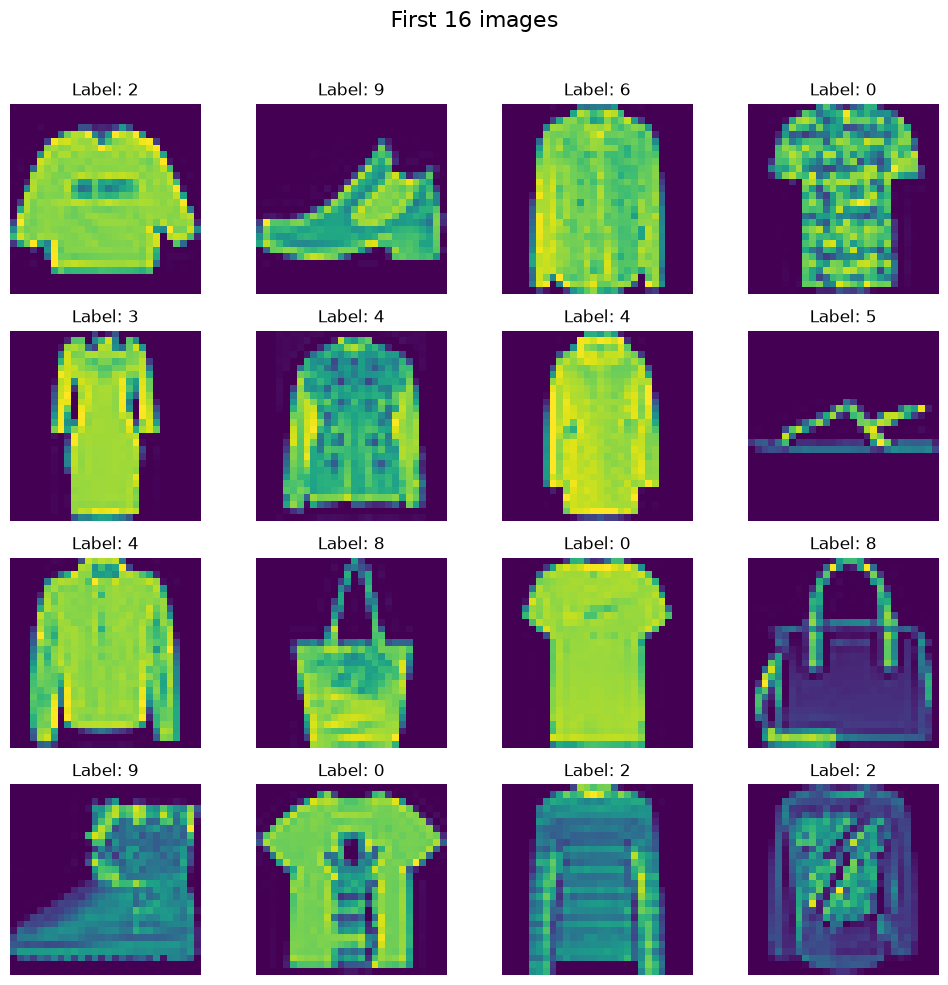

In [26]:
# Create 4x4 (16 images) grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images", fontsize=16)

# plot the first 16 images from the dataset
for i, ax, in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28) # reshape to 28*28
  ax.imshow(img) # display in grayscale
  ax.axis('off') # remove axis for cleaner look
  ax.set_title(f"Label: {df.iloc[i, 0]}") # show the label
  
plt.tight_layout(rect=[0, 0, 1, 0.96]) # adjust layout to fit the title
plt.show()

In [27]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# scaling the features
# in the dataset, the pixel values are within 0 to 255. 
# It is better for neural networking to make the traning values
# between 0 to 1. That's why diving all by 255.
X_train = X_train / 255.0
X_test = X_test / 255.0

In [30]:
# Create CustomDataset Class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)
    
  def __len__(self):
    return len(self.features)
  
  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [31]:
# Create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [32]:
test_dataset = CustomDataset(X_test, y_test)

In [33]:
class MyNN(nn.Module):
  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):
    super().__init__()
    
    layers = []
    
    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      # last layer's output neurons will be next layer's input neurons
      input_dim = neurons_per_layer
    
    layers.append(nn.Linear(neurons_per_layer, output_dim)) # same logic as the for loop
    
    self.model = nn.Sequential(*layers) 
    # layers = [layer1, layer2, ...]; *layers = layer1, layer2.. (the * before an array unpacks the elements into a comma separated list)
  def forward(self, x):
    return self.model(x)
    

In [34]:
# Objective function:
def objective(trial):
  # next hyperparameter values for the next trial from the search space
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5) # between 1-5, num_hidden_layers is the name given by us
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True) # the scale would be logarithmic
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128]) # trials.categorical selects from the choices given as the second parameter array
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
  
  # Create train and test loader
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
  
  # model init
  input_dim = 784
  output_dim = 10 # fixed from the dataset
  
  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)
  
  # Loss Function
  criterion = nn.CrossEntropyLoss()

  # Optimizer
  if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  
  # training loop
  for _ in range(epochs):
    for batch_features, batch_labels in train_loader:
      # move data to GPU
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      
      # forward pass
      outputs = model(batch_features)
      
      # calculate loss
      loss = criterion(outputs, batch_labels)
      
      # backpropagation
      optimizer.zero_grad()
      loss.backward()
      
      # gradients update
      optimizer.step()
      
  
  # evaluation
  model.eval()
  
  # evaluation code
  # will use test dataset for evaluation the model
  total = 0
  correct = 0

  with torch.no_grad(): # as we do not need gradient while predicting 
    for batch_features, batch_labels in test_loader:
      # move data to GPU
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      outputs = model(batch_features)
      _, predicted = torch.max(outputs, 1)
      total = total + batch_labels.shape[0]
      correct = correct + (predicted == batch_labels).sum().item()
    
    accuracy = correct / total
    
  return accuracy

In [ ]:
!pip install optuna

In [36]:
import optuna

study = optuna.create_study(direction='maximize') 
# since we are working with accuracy improvement, putting the direction as 'maximize'

[I 2026-09-28 13:52:15,995] A new study created in memory with name: no-name-973d44cc-929a-4fa9-aecc-4eccb6680fbb


In [37]:
study.optimize(objective, n_trials=10)

[I 2026-09-28 13:54:25,599] Trial 0 finished with value: 0.8605833333333334 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 16, 'epochs': 50, 'learning_rate': 0.0036450316968632255, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0001942310240496358}. Best is trial 0 with value: 0.8605833333333334.
[I 2026-09-28 14:03:12,162] Trial 1 finished with value: 0.8663333333333333 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 88, 'epochs': 50, 'learning_rate': 1.9923461191372678e-05, 'dropout_rate': 0.4, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00012782202919248018}. Best is trial 1 with value: 0.8663333333333333.
[I 2026-09-28 14:05:50,793] Trial 2 finished with value: 0.3775 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 8, 'epochs': 50, 'learning_rate': 0.003185173432209928, 'dropout_rate': 0.4, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00045743542909264603}. Best is trial 1 with value: 0

In [38]:
study.best_value

0.8919166666666667

In [39]:
study.best_params

{'num_hidden_layers': 4,
 'neurons_per_layer': 96,
 'epochs': 50,
 'learning_rate': 8.690285327157868e-05,
 'dropout_rate': 0.2,
 'batch_size': 32,
 'optimizer': 'RMSprop',
 'weight_decay': 4.687819432528056e-05}

#### Some improvement processes

- We can increase the number of trials `(n_trials)` in the study optimization function
- We can increase the range of the search spaces into the objective functions


#### Optuna x MLflow - Industry standard practices

**Experiment Tracking:**

- It is done during hyperparameter tuning
- Logging each trial using a tool named `MLflow`
  - Parameter values
  - Matrix logging (how much accuracy dropped or increased)
